## Install libraries (optional)

In [ ]:
!pip install -q cartopy

## Import required libraries and read the data

In [25]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

# read the district file
dist_fp = r'/content/India_District_2023.shp'
gdf = gpd.read_file(dist_fp)
gdf.head()

,fid,state23,st_code,dist23,di_code,st_di23,Shape_Leng,Shape_Area,GeoName,GEOID,class,floodindex,geometry
0,1.0,GUJARAT,24,MORBI,673,"GUJARAT, MORBI",539476.764723,4.791280e+09,"GUJARAT, MORBI",x24673,0,High,"POLYGON ((71.27029 23.15576, 71.27005 23.15116..."
1,2.0,GUJARAT,24,AHMADABAD,438,"GUJARAT, AHMADABAD",857254.094647,6.966374e+09,"GUJARAT, AHMADABAD",x24438,-1,NoData,"POLYGON ((71.97206 23.05747, 71.96077 23.04709..."
2,3.0,GUJARAT,24,ANAND,440,"GUJARAT, ANAND",393046.690523,3.054307e+09,"GUJARAT, ANAND",x24440,0,High,"POLYGON ((73.21882 22.62125, 73.216 22.62028, ..."
3,4.0,GUJARAT,24,DEVBHUMI DWARKA,674,"GUJARAT, DEVBHUMI DWARKA",661732.986530,4.002784e+09,"GUJARAT, DEVBHUMI DWARKA",x24674,0,High,"MULTIPOLYGON (((69.7547 22.41837, 69.75085 22...."
4,5.0,GUJARAT,24,JAMNAGAR,447,"GUJARAT, JAMNAGAR",737428.071884,5.694271e+09,"GUJARAT, JAMNAGAR",x24447,2,Medium,"MULTIPOLYGON (((70.49275 22.85182, 70.49379 22..."


## Aggregated the data to state level

In [69]:
%%time

# 1. Define a helper to handle the mode (takes the first result if there is a tie)
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else None

# 2. Dissolve the districts into states
# We group by 'state' and apply 'get_mode' to the 'floodrisk' column
gdf_state = gdf.dissolve(
    by='state23',
    aggfunc={'floodindex': get_mode}
)

# 3. Check the result
# 'state' is now the index, and the geometry is the combined state shape
gdf_state.reset_index(inplace=True)
gdf_state.set_crs("EPSG:4326", allow_override=True, inplace=True)

# delete holes
def remove_holes(geometry):
    if geometry.geom_type == 'Polygon':
        return Polygon(geometry.exterior)
    elif geometry.geom_type == 'MultiPolygon':
        # Reconstruct each part of the MultiPolygon without holes
        return MultiPolygon([Polygon(p.exterior) for p in geometry.geoms])
    return geometry
gdf_state.geometry = gdf_state.geometry.apply(remove_holes)

gdf_state.head()

,state23,geometry,floodindex
0,ANDAMAN & NICOBAR,"MULTIPOLYGON (((92.54257 10.88393, 92.54772 10...",NoData
1,ANDHRA PRADESH,"MULTIPOLYGON (((79.31876 13.11333, 79.31857 13...",High
2,ARUNACHAL PRADESH,"POLYGON ((93.3241 26.96008, 93.29777 26.95634,...",Very Low
3,ASSAM,"POLYGON ((92.71138 24.40722, 92.71327 24.40332...",Very High
4,BIHAR,"POLYGON ((85.37952 24.55112, 85.39187 24.54648...",High


## Plot the maps

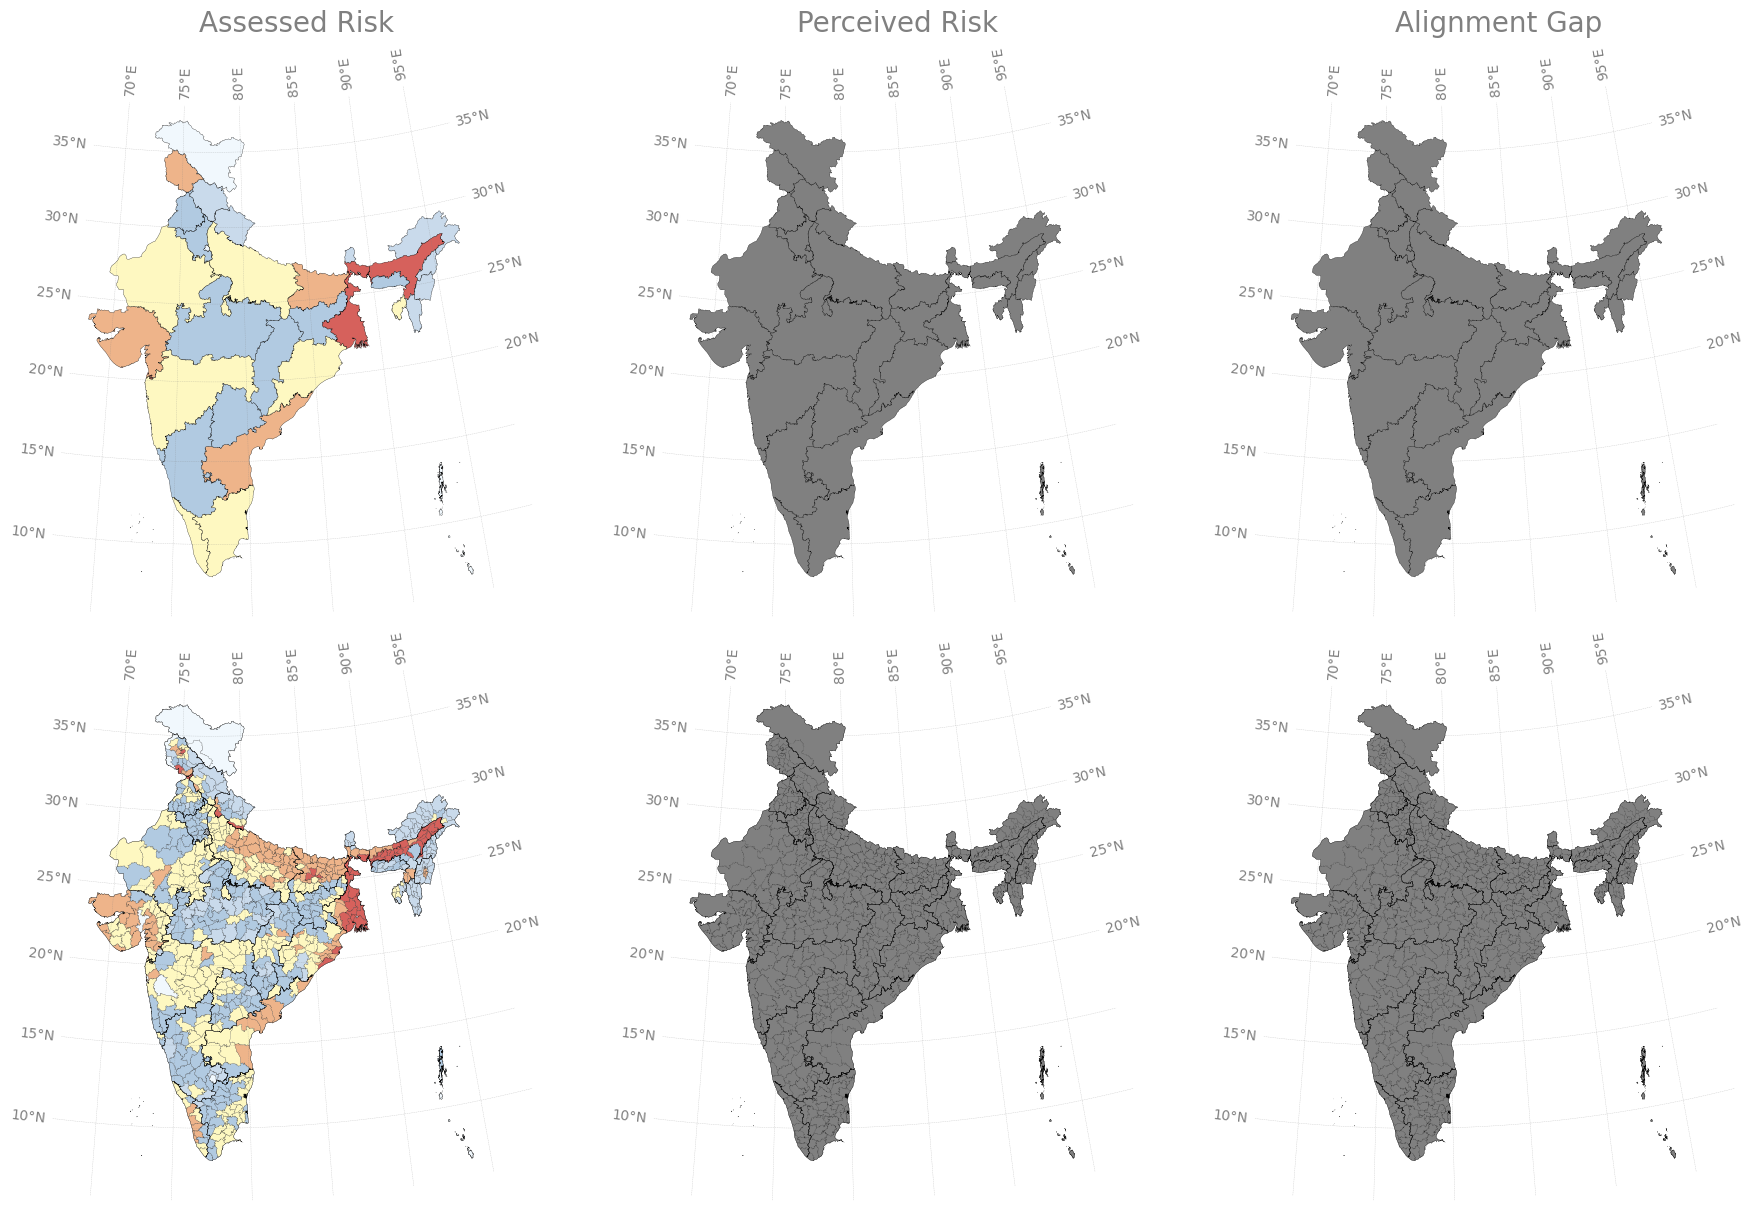

CPU times: user 4min 19s, sys: 324 ms, total: 4min 19s
Wall time: 4min 22s


In [76]:
%%time

import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.colors as mcolors

# --- 1. GLOBAL SETTINGS ---
STRAIGHT_LON = 77.5
PROJ = ccrs.LambertConformal(central_longitude=STRAIGHT_LON, central_latitude=23.0)
DATA_CRS = ccrs.PlateCarree()
BOUNDS = gdf.total_bounds
PAD = 1.0

# --- 2. PRE-CALCULATE THE CURVED BOUNDARY ---
n = 100
lons = np.r_[np.linspace(BOUNDS[0]-PAD, BOUNDS[2]+PAD, n), np.full(n, BOUNDS[2]+PAD),
             np.linspace(BOUNDS[2]+PAD, BOUNDS[0]-PAD, n), np.full(n, BOUNDS[0]-PAD)]
lats = np.r_[np.full(n, BOUNDS[1]-PAD), np.linspace(BOUNDS[1]-PAD, BOUNDS[3]+PAD, n),
             np.full(n, BOUNDS[3]+PAD), np.linspace(BOUNDS[3]+PAD, BOUNDS[1]-PAD, n)]
AOI_PATH = mpath.Path(np.column_stack([lons, lats]))

# --- 3. THE UPDATED FORMATTING FUNCTION ---
def format_india_map(ax, title):
    """Applies projection, hides spines, adds graticules, and disables right labels."""
    # Clip the map to our custom area
    ax.set_boundary(AOI_PATH, transform=DATA_CRS)
    ax.set_extent([BOUNDS[0]-PAD, BOUNDS[2]+PAD, BOUNDS[1]-PAD, BOUNDS[3]+PAD], crs=DATA_CRS)

    # REMOVE OUTER BOUNDARY: Hide the spines (the map frame)
    ax.spines['geo'].set_visible(False)   # For newer Cartopy

    # GRATICULES: Add and customize labels
    # Force labels to stay outside the map area (fixes the "middle of the map" issue)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--',
        x_inline=False, y_inline=False
    )

    # TURN OFF RIGHT LABELS (and top labels for a cleaner look)
    gl.top_labels = True      # Enable top
    gl.left_labels = True     # Enable left
    gl.right_labels = False    # Turn off right
    gl.bottom_labels = False   # Turn off bottom (cleans up the middle of the grid)
    gl.padding = 10  # Increases distance between labels and the map data

    # FONT SIZE CHANGES HERE
    gl.xlabel_style = {'size': 10, 'color': 'gray', 'weight': 'normal'}
    gl.ylabel_style = {'size': 10, 'color': 'gray', 'weight': 'normal'}

    ax.set_title(title, fontsize=20, pad=10, color='gray')

# --- 4. CREATE THE FIGURE ---
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': PROJ}, constrained_layout=True)
(ax1, ax2, ax3), (ax4, ax5, ax6) = axs # Unpack for easy access

# Mapping floodindex to the exact colors from the HHI scale
# Using a logical progression from Cool (Low) to Warm (High)
flood_color_map = {
    'Very Low':  '#c9daeb', # Lightest Blue
    'Low':       '#b1cae1', # Light Blue
    'Medium':    '#fef8c1', # Pale Yellow (The transition point)
    'High':      '#eeb48a', # Light Orange
    'Very High': '#d6615c', # Burnt Red/Orange
    'NoData':    '#f1f8fd'  # Near-white/Grey for missing info
}

# --- 5. INDIVIDUAL PLOTTING LINES ---
# Variable 1: Plotting your GDF with standard orange
format_india_map(ax1, "Assessed Risk")
colors_ax1 = [flood_color_map.get(val, 'white') for val in gdf_state['floodindex']]
gdf_state.plot(ax=ax1, color=colors_ax1, transform=DATA_CRS, edgecolor='black', linewidth=0.2)

# Variable 2: You can change the facecolor here
format_india_map(ax2, "Perceived Risk")
gdf_state.plot(ax=ax2, transform=DATA_CRS, facecolor='gray', edgecolor='black', linewidth=0.2)

# Variable 3: Example of adding a different alpha/transparency
format_india_map(ax3, "Alignment Gap")
gdf_state.plot(ax=ax3, transform=DATA_CRS, facecolor='gray', edgecolor='black', linewidth=0.2)

# Variable 4: Ready for your next variable
format_india_map(ax4, "")
colors_ax4 = [flood_color_map.get(val, 'white') for val in gdf['floodindex']]
gdf.plot(ax=ax4, color=colors_ax4, transform=DATA_CRS, edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax4, transform=DATA_CRS, color='black', linewidth=0.2)

# Variable 5: Ready for your next variable
format_india_map(ax5, "")
gdf.plot(ax=ax5, transform=DATA_CRS, facecolor='gray', edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax5, transform=DATA_CRS, color='black', linewidth=0.2)

# Variable 6: Ready for your next variable
format_india_map(ax6, "")
gdf.plot(ax=ax6, transform=DATA_CRS, facecolor='gray', edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax6, transform=DATA_CRS, color='black', linewidth=0.2)

plt.savefig('India_FloodRisk_ActualPerceived.png', dpi=300, bbox_inches='tight')
plt.show()